In [1]:
import pandas as pd
from rouge_score import rouge_scorer
from sarathi.benchmark.request_generator.real_request_generator import RealRequestGenerator
from sarathi.benchmark.config import Config

ModuleNotFoundError: No module named 'pandas'

In [2]:
request_generator = RealRequestGenerator(config=Config({'num_requests': 100}))
cnn_prompts = request_generator.get_cnn_prompts()


In [3]:
scorer = rouge_scorer.RougeScorer(['rougeL'])

def get_rougeL_score(prompt, output):
    return scorer.score(prompt, output)['rougeL']

def get_avg_rougeL_score(prompts, outputs):
    precisions = []
    recalls = []
    fmeasures = []
    for prompt, output in zip(prompts, outputs):
        scores = get_rougeL_score(prompt, output)
        precisions.append(scores.precision)
        recalls.append(scores.recall)
        fmeasures.append(scores.fmeasure)
    return sum(precisions) / len(precisions), sum(recalls) / len(recalls), sum(fmeasures) / len(fmeasures)


In [4]:
policies = [
  "rebatching_0.99_40",
  "rebatching_0.99_60",
  "rebatching_0.95_40",
  "rebatching_0.95_60",
  "rebatching_0.9_40",
  "rebatching_0.9_60",
  "rebatching_0.8_40",
  "rebatching_0.8_60",
  "rebatching_0.7_40",
  "rebatching_0.7_60",
]
# policies = ["ee_nobatch", "off","eager", "lazy", "average", "rebatching"]
throughputs = []
precisions = []
recalls = []
fmeasures = []

ee_df = pd.read_csv(f"/workspace/vattention-ee/outputs_70b_daniel/req_100_batch_4_csv/eager_0.99.csv")
avg_precision, avg_recall, avg_fmeasure = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
precisions.append(avg_precision)
recalls.append(avg_recall)
fmeasures.append(avg_fmeasure)

for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/vattention-ee/outputs_70b_daniel/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_fmeasure = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    precisions.append(avg_precision)
    recalls.append(avg_recall)
    fmeasures.append(avg_fmeasure)
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "precision": precisions,
    "recall": recalls,
    "fmeasure": fmeasures
})
df

,policy,throughput,precision,recall,fmeasure
0,rebatching_0.99_40,70.555694,0.001786,0.000581,0.000877
1,rebatching_0.99_60,54.673341,0.006690,0.003952,0.004314
2,rebatching_0.95_40,68.282528,0.003128,0.000588,0.000763
3,rebatching_0.95_60,62.925099,0.003846,0.002690,0.003021
4,rebatching_0.9_40,74.488366,0.000493,0.000226,0.000294
5,rebatching_0.9_60,64.923885,0.004500,0.003015,0.003373
6,rebatching_0.8_40,75.052770,0.000685,0.000450,0.000485
7,rebatching_0.8_60,66.967257,0.003697,0.002605,0.002924
8,rebatching_0.7_40,77.038868,0.001817,0.000415,0.000468
9,rebatching_0.7_60,64.973280,0.005826,0.003097,0.003645


In [5]:
policies = [
  "rebatching_0.99_40",
  "rebatching_0.99_60",
  "rebatching_0.95_40",
  "rebatching_0.95_60",
  "rebatching_0.9_40",
  "rebatching_0.9_60",
  "rebatching_0.8_40",
  "rebatching_0.8_60",
  "rebatching_0.7_40",
  "rebatching_0.7_60",
]
# policies = ["off","eager", "average", "rebatching"]
throughputs = []
precisions = []
recalls = []
fmeasures = []


for policy in policies:
    df = pd.read_csv(f"/workspace/vattention-ee/outputs_70b_daniel/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_fmeasure = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    precisions.append(avg_precision)
    recalls.append(avg_recall)
    fmeasures.append(avg_fmeasure)
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "precision": precisions,
    "recall": recalls,
    "fmeasure": fmeasures
})
df

,policy,throughput,precision,recall,fmeasure
0,rebatching_0.99_40,74.907159,0.004053,0.000807,0.001137
1,rebatching_0.99_60,54.673341,0.006690,0.003952,0.004314
2,rebatching_0.95_40,68.282528,0.003128,0.000588,0.000763
3,rebatching_0.95_60,62.925099,0.003846,0.002690,0.003021
4,rebatching_0.9_40,74.488366,0.000493,0.000226,0.000294
5,rebatching_0.9_60,64.923885,0.004500,0.003015,0.003373
6,rebatching_0.8_40,75.052770,0.000685,0.000450,0.000485
7,rebatching_0.8_60,66.967257,0.003697,0.002605,0.002924
8,rebatching_0.7_40,77.038868,0.001817,0.000415,0.000468
9,rebatching_0.7_60,64.973280,0.005826,0.003097,0.003645


In [7]:
policies = [
  "rebatching_0.99_40",
  "rebatching_0.99_60",
  "rebatching_0.95_40",
  "rebatching_0.95_60",
  "rebatching_0.9_40",
  "rebatching_0.9_60",
  "rebatching_0.8_40",
  "rebatching_0.8_60",
  "rebatching_0.7_40",
  "rebatching_0.7_60",
]
# policies = ["ee_nobatch", "off","eager", "lazy", "average", "rebatching"]
throughputs = []
rouge_scores = []
tpot = []

num_ee_tokens = []
num_no_ee_tokens = []
avg_conf_score = []
avg_conf_score_ee = []


ee_df = pd.read_csv(f"/workspace/vattention-ee/outputs_70b_daniel/req_100_batch_4_csv/eager_0.99.csv")
avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, ee_df.output)
throughputs.append(ee_df.throughput.mean())
rouge_scores.append(avg_rouge_score)

tpot.append(ee_df.tpot.values[0])
num_ee_tokens.append(ee_df.num_ee_tokens.values[0])
num_no_ee_tokens.append(ee_df.num_no_ee_tokens.values[0])
avg_conf_score.append(ee_df.avg_conf_score.values[0])
avg_conf_score_ee.append(ee_df.avg_conf_score_ee.values[0])

for policy in policies[1:]:
    df = pd.read_csv(f"/workspace/vattention-ee/outputs_70b_daniel/req_100_batch_4_csv/{policy}.csv")
    avg_precision, avg_recall, avg_rouge_score = get_avg_rougeL_score(cnn_prompts, df.output)
    throughputs.append(df.throughput.mean())
    rouge_scores.append(avg_rouge_score)

    tpot.append(df.tpot.values[0])
    num_ee_tokens.append(df.num_ee_tokens.values[0])
    num_no_ee_tokens.append(df.num_no_ee_tokens.values[0])
    avg_conf_score.append(df.avg_conf_score.values[0])
    avg_conf_score_ee.append(df.avg_conf_score_ee.values[0])
df = pd.DataFrame({
    "policy": policies,
    "throughput": throughputs,
    "TPOT": tpot,
    "ROUGE-L": rouge_scores,
    "num_ee_tokens": num_ee_tokens,
    "num_no_ee_tokens": num_no_ee_tokens,
    "avg_conf_score": avg_conf_score,
    "avg_conf_score_ee": avg_conf_score_ee
})
df

,policy,throughput,TPOT,ROUGE-L,num_ee_tokens,num_no_ee_tokens,avg_conf_score,avg_conf_score_ee
0,rebatching_0.99_40,70.555694,0.012424,0.000877,2440,2742,0.885481,0.931205
1,rebatching_0.99_60,54.673341,0.016886,0.004314,20191,30862,0.614494,0.769012
2,rebatching_0.95_40,68.282528,0.013292,0.000763,25210,26111,0.920962,0.938628
3,rebatching_0.95_60,62.925099,0.014615,0.003021,24411,26862,0.756019,0.793530
4,rebatching_0.9_40,74.488366,0.012218,0.000294,25392,25929,0.933487,0.944530
5,rebatching_0.9_60,64.923885,0.014110,0.003373,24659,26589,0.759625,0.788982
6,rebatching_0.8_40,75.052770,0.012070,0.000485,25408,25913,0.931278,0.941848
7,rebatching_0.8_60,66.967257,0.013742,0.002924,25325,25996,0.759695,0.770708
8,rebatching_0.7_40,77.038868,0.011787,0.000468,25448,25873,0.936645,0.945815
9,rebatching_0.7_60,64.973280,0.014143,0.003645,25389,25932,0.772855,0.782227


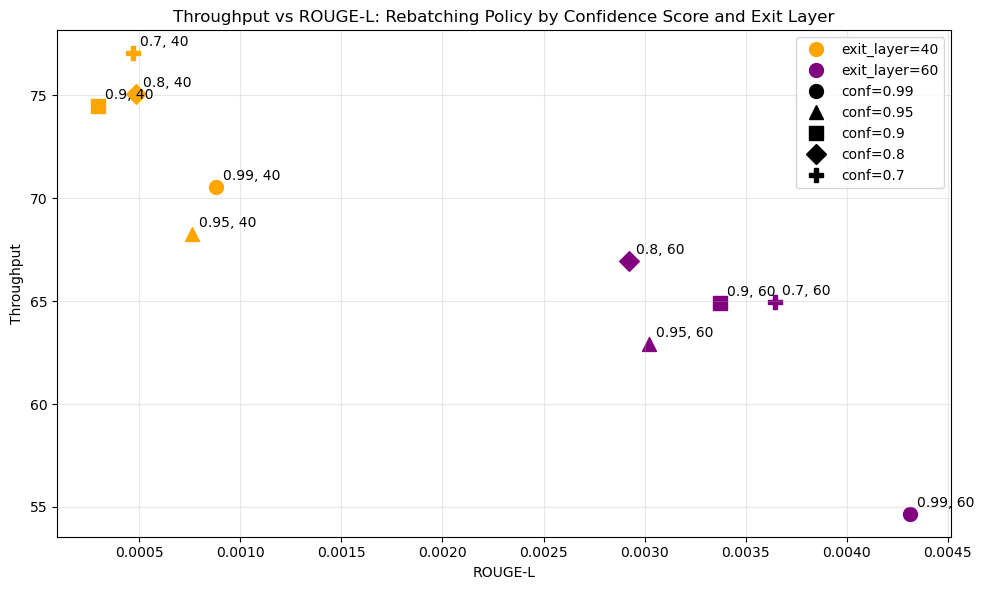

In [14]:
from matplotlib import pyplot as plt
import matplotlib.lines as mlines
import os

# Marker for conf_score
conf_marker = {
    '0.99': 'o',   # circle
    '0.95': '^',   # triangle
    '0.9': 's',    # square
    '0.8': 'D',    # diamond
    '0.7': 'P',    # plus (filled)
}

# Color for exit_layer
exit_color = {
    '40': 'orange',
    '60': 'purple',
}

plt.figure(figsize=(10, 6))

for i, row in df.iterrows():
    policy_full = row['policy']
    # Parse policy and conf_score (now always rebatching_<conf>)
    if '_' in policy_full:
        policy, conf_score, exit_layer = policy_full.split('_')
    else:
        policy, conf_score, exit_layer = policy_full, '', 40

    color = exit_color.get(exit_layer, 'gray')
    marker = conf_marker.get(conf_score, 'o')
    plt.scatter(row['ROUGE-L'], row['throughput'], color=color, marker=marker, s=100)
    # Annotate with conf_score and exit_layer for clarity
    plt.annotate(f"{conf_score}, {exit_layer}", (row['ROUGE-L'], row['throughput']),
                 textcoords="offset points", xytext=(5, 5), ha='left')

# Custom legend for exit_layer colors
exit_legend = [
    mlines.Line2D([], [], color='orange', marker='o', linestyle='None', markersize=10, label='exit_layer=40'),
    mlines.Line2D([], [], color='purple', marker='o', linestyle='None', markersize=10, label='exit_layer=60'),
]

# Custom legend for conf_score markers (all in black for clarity)
conf_legend = [
    mlines.Line2D([], [], color='black', marker='o', linestyle='None', markersize=10, label='conf=0.99'),
    mlines.Line2D([], [], color='black', marker='^', linestyle='None', markersize=10, label='conf=0.95'),
    mlines.Line2D([], [], color='black', marker='s', linestyle='None', markersize=10, label='conf=0.9'),
    mlines.Line2D([], [], color='black', marker='D', linestyle='None', markersize=10, label='conf=0.8'),
    mlines.Line2D([], [], color='black', marker='P', linestyle='None', markersize=10, label='conf=0.7'),
]

plt.legend(handles=exit_legend + conf_legend, loc='best', fontsize=10)

plt.xlabel("ROUGE-L")
plt.ylabel("Throughput")
plt.title("Throughput vs ROUGE-L: Rebatching Policy by Confidence Score and Exit Layer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()